In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt 

# class twoDPoisson:
#     """Finite-element solver for 2D poisson on a rectangular domain (a,b)⨉(c,d)
#     """
#     def __init__(self, a, b, c, d, resolution, f):
#         self.a, self.b, self.c, self.d = a, b, c, d
#         self.f = f
        
#         # grid for representing functions using basis functions
#         x = np.linspace(a, b, (resolution + 1))
#         y = np.linspace(c, d, int((resolution + 1) * (np.abs(d-c)/np.abs(b-a))))
        
#         # grid for basis functions 
#         x_ = np.linspace(a, b, 100 * (resolution + 1))
#         y_ = np.linspace(c, d, 100 * int((resolution + 1) * (np.abs(d-c)/np.abs(b-a))))

#         self.grid_x, self.grid_y = np.meshgrid(x, y, indexing='xy')
#         self.basis_x, self.basis_y = np.meshgrid(x_, y_, indexing='xy')
        
#         self.h = ((self.b - self.a) / (2 * resolution))
#         print(f"grid spacing is {self.h}")
    
#     def get_basis(self, i):
#         a, b = self.grid_x[:,:-1].flatten()[i], self.grid_y[:,:-1].flatten()[i]
        
#         # Pre-calculate relative distances from center to make formulas cleaner
#         X = self.basis_x - a
#         Y = self.basis_y - b
#         h = self.h
        
#         tent = np.zeros_like(self.basis_x)
        
#         # --- Face 1 ---
#         mask_1 = (h <= X) & (X <= 2*h) & (h <= Y) & (Y <= 3*h - X)
#         tent[mask_1] = 3 - (X[mask_1] + Y[mask_1]) / h
        
#         # --- Face 2 ---
#         mask_2 = (0 <= X) & (X <= h) & (h - X <= Y) & (Y <= h)
#         tent[mask_2] = (X[mask_2] + Y[mask_2]) / h - 1
        
#         # --- Face 3 ---
#         mask_3 = (h <= X) & (X <= 2*h) & (2*h - X <= Y) & (Y <= h)
#         tent[mask_3] = 2 - X[mask_3] / h
        
#         # --- Face 4 ---
#         mask_4 = (0 <= Y) & (Y <= h) & (h <= X) & (X <= 2*h - Y)
#         tent[mask_4] = Y[mask_4] / h
        
#         # --- Face 5 ---
#         mask_5 = (0 <= X) & (X <= h) & (h <= Y) & (Y <= 2*h - X)
#         tent[mask_5] = X[mask_5] / h
        
#         # --- Face 6 ---
#         mask_6 = (0 <= X) & (X <= h) & (2*h - X <= Y) & (Y <= 2*h)
#         tent[mask_6] = 2 - Y[mask_6] / h

#         return tent
        

#     def init_plot(self):
#         fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
#         ax.set_zlim(0,1)
#         ax.set_xlim(self.a, self.b)
#         ax.set_ylim(self.c, self.d)
#         ax.set_aspect(aspect='equalxy')
#         return fig, ax

        

grid spacing is 1.25


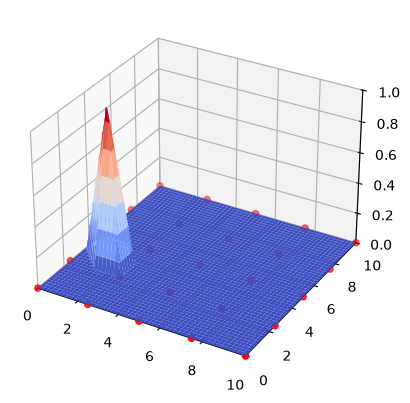

In [ ]:
# solver = twoDPoisson(0,10.0,0,10.0,resolution=4, f=lambda x : x)
# tent_basis = solver.get_basis(4)
# fig, ax = solver.init_plot()
# ax.scatter(solver.grid_x, solver.grid_y, color='red')
# ax.plot_surface(solver.basis_x, solver.basis_y, tent_basis, cmap='coolwarm')




In [3]:
import matplotlib
print(matplotlib.__version__)

3.11.0


In [1]:
import sys
from pathlib import Path
import ipywidgets as wdgt

# Calculates the absolute path to your 'src' directory
sys.path.append('src')

from src.twoDPoissonFEM import twoDPoisson

slider_resol = wdgt.FloatSlider(value=3.0, min=1.0, max=6.0, step=1.0)
slider_pos = wdgt.FloatSlider(value=0.0, min=0.0, max=36.0, step=1.0)

def plot(resol, pos):
    solver = twoDPoisson(0,10.0,0,10.0,resolution=resol, f=lambda x : x)
    if pos < resol * resol:
        tent_basis = solver.get_basis(pos)
        fig, ax = solver.init_plot()
        ax.scatter(solver.grid_x, solver.grid_y, color='red')
        ax.plot_surface(solver.basis_x, solver.basis_y, tent_basis, cmap='coolwarm')

wdgt.interactive(plot, resol=slider_resol, pos=slider_pos)

ModuleNotFoundError: No module named 'ipywidgets'

In [4]:
import sys
# sys.path.append('src')

from src.twoDPoissonFEM import twoDPoisson
solver = twoDPoisson()

TypeError: twoDPoisson.__init__() missing 6 required positional arguments: 'a', 'b', 'c', 'd', 'resolution', and 'f'